# **Hangman**

In dit notebook bouwen we stap voor stap een steeds slimmere **rule-based agent** voor het spel Hangman. We beginnen bij een agent die volledig willekeurig gokt en eindigen bij een agent die op basis van **informatietheorie** de optimale letter kiest.

Elke strategie voegt precies één laag kennis of redenering toe boven de vorige:

| # | Strategie | Kernidee |
|---|---|---|
| 1 | **Random** | Willekeurige letter — puur toeval |
| 2 | **Frequentie** | Letters in volgorde van Engelse letterfrequentie |
| 3 | **Positionele Frequentie** | Letterfrequentie *per positie* in de woordenlijst |
| 4 | **Woordeliminatie** | Actief filteren van onmogelijke woorden na elke gok |
| 5 | **Entropie** | Letter kiezen die de kandidatenlijst het meest *informatief* opsplitst |

In [44]:
import sys, os
sys.path.insert(0, os.getcwd())

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
from IPython.display import clear_output
import time
import numpy as np
import random as _random
import warnings

from environment import HangmanEnvironment
from agents import (
    RandomAgent, FrequencyAgent, PositionalFrequencyAgent,
    WordListEliminationAgent, EntropyAgent, get_all_agents
)

warnings.filterwarnings("ignore", category=UserWarning)

In [45]:
# ── Drawing helpers ────────────────────────────────────────────────────────
PALETTE = {
    "bg":         "#1A1A2E",
    "panel":      "#16213E",
    "accent":     "#E94560",
    "correct":    "#0F9B58",
    "wrong":      "#E94560",
    "guessed":    "#2980B9",
    "neutral":    "#2C2C54",
    "text":       "#EAEAEA",
    "subtext":    "#A0A0C0",
    "gold":       "#F4D03F",
    "gallows":    "#C0C0D0",
}


def draw_gallows(ax, wrong: int, max_wrong: int = 10):
    """Draw the hangman figure — dark-theme style."""
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 12)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_facecolor(PALETTE["panel"])

    lw_frame = 3.5
    gc = PALETTE["gallows"]

    # base
    ax.plot([1, 9], [1, 1],   color=gc, lw=lw_frame, solid_capstyle='round')
    # pole
    ax.plot([3, 3], [1, 11],  color=gc, lw=lw_frame, solid_capstyle='round')
    # top beam
    ax.plot([3, 7], [11, 11], color=gc, lw=lw_frame, solid_capstyle='round')
    # diagonal brace
    ax.plot([3, 5.2], [8.5, 11], color=gc, lw=2, alpha=0.5, solid_capstyle='round')
    # rope
    ax.plot([7, 7], [11, 9.6], color=gc, lw=2, solid_capstyle='round')

    # Progress dots along base (remaining lives)
    remaining = max_wrong - wrong
    for i in range(max_wrong):
        dot_color = PALETTE["correct"] if i < remaining else PALETTE["wrong"]
        ax.plot(1.0 + i * (8.0 / (max_wrong - 1)), 0.4,
                'o', color=dot_color, markersize=4)

    dead = wrong >= max_wrong
    body_color = PALETTE["wrong"] if dead else PALETTE["text"]
    lw_body = 2.5

    parts = [
        # (min_wrong, draw_fn)
        (1, lambda: ax.add_patch(
            plt.Circle((7, 8.85), 0.75, color=body_color, fill=False, lw=lw_body))),
        (2, lambda: ax.plot([7, 7], [8.1, 5.5],  color=body_color, lw=lw_body, solid_capstyle='round')),
        (3, lambda: ax.plot([7, 5.0], [7.4, 6.0], color=body_color, lw=lw_body, solid_capstyle='round')),
        (4, lambda: ax.plot([7, 9.0], [7.4, 6.0], color=body_color, lw=lw_body, solid_capstyle='round')),
        (5, lambda: ax.plot([7, 5.3], [5.5, 3.8], color=body_color, lw=lw_body, solid_capstyle='round')),
        (6, lambda: ax.plot([7, 8.7], [5.5, 3.8], color=body_color, lw=lw_body, solid_capstyle='round')),
        (7, lambda: ax.plot([5.3, 4.2], [3.8, 3.8], color=body_color, lw=lw_body, solid_capstyle='round')),
        (8, lambda: ax.plot([8.7, 9.8], [3.8, 3.8], color=body_color, lw=lw_body, solid_capstyle='round')),
        (9, lambda: ax.plot([5.3, 4.8], [3.8, 2.8], color=body_color, lw=lw_body, solid_capstyle='round')),
        (10, lambda: ax.plot([8.7, 9.2], [3.8, 2.8], color=body_color, lw=lw_body, solid_capstyle='round')),
    ]
    for threshold, fn in parts:
        if wrong >= threshold:
            fn()

    # Face expressions when dead
    if dead:
        ax.text(6.65, 8.9, "x", ha='center', va='center',
                fontsize=9, color=PALETTE["wrong"], fontweight='bold')
        ax.text(7.35, 8.9, "x", ha='center', va='center',
                fontsize=9, color=PALETTE["wrong"], fontweight='bold')
        ax.text(7.0, 8.4, "~", ha='center', va='center',
                fontsize=10, color=PALETTE["wrong"])


def draw_word(ax, masked_word: str, won: bool, secret_word: str = ""):
    """Draw the masked/revealed word as letter tiles — dark theme."""
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_facecolor(PALETTE["panel"])

    n = len(masked_word)
    tile_w = min(0.88 / n, 0.11)
    gap = tile_w * 0.25
    total = n * tile_w + (n - 1) * gap
    x0 = (1 - total) / 2

    for i, ch in enumerate(masked_word):
        x = x0 + i * (tile_w + gap)
        revealed = ch != '_'
        if won and revealed:
            bg = PALETTE["correct"]
            edge = "#0D7A45"
        elif revealed:
            bg = "#1C5E8A"
            edge = "#2980B9"
        else:
            bg = PALETTE["neutral"]
            edge = "#3C3C6E"

        rect = mpatches.FancyBboxPatch(
            (x, 0.22), tile_w, 0.56,
            boxstyle='round,pad=0.015',
            facecolor=bg, edgecolor=edge, lw=1.5
        )
        ax.add_patch(rect)
        if revealed:
            ax.text(x + tile_w / 2, 0.50, ch.upper(),
                    ha='center', va='center', fontsize=13,
                    fontweight='bold', color='white')
        else:
            # Underscore hint
            ax.plot([x + tile_w * 0.15, x + tile_w * 0.85], [0.24, 0.24],
                    color="#5C5C8A", lw=1.5)


def draw_letters(ax, guessed: set, secret_word: str, remaining: list):
    """Draw the alphabet — dark-theme coloured tiles."""
    ax.set_xlim(0, 26)
    ax.set_ylim(0, 2)
    ax.axis('off')
    ax.set_facecolor(PALETTE["bg"])

    alphabet = 'abcdefghijklmnopqrstuvwxyz'
    for i, ch in enumerate(alphabet):
        if ch in guessed:
            if ch in secret_word:
                bg, tc, edge = PALETTE["correct"], "white", "#0A7040"
            else:
                bg, tc, edge = PALETTE["wrong"], "white", "#B03040"
        else:
            bg, tc, edge = PALETTE["neutral"], PALETTE["subtext"], "#3C3C6E"

        rect = mpatches.FancyBboxPatch(
            (i + 0.08, 0.15), 0.84, 1.2,
            boxstyle='round,pad=0.05',
            facecolor=bg, edgecolor=edge, lw=0.8
        )
        ax.add_patch(rect)
        ax.text(i + 0.5, 0.75, ch.upper(),
                ha='center', va='center', fontsize=8,
                fontweight='bold', color=tc)


def _progress_bar(ax, wrong, max_wrong):
    """Small horizontal lives bar in the word panel."""
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    frac = max(0, (max_wrong - wrong) / max_wrong)
    # Background
    ax.barh(0.5, 1.0, height=0.35, color="#2C2C54", left=0)
    # Filled
    bar_color = PALETTE["correct"] if wrong < max_wrong * 0.5 else \
                PALETTE["gold"]   if wrong < max_wrong * 0.8 else \
                PALETTE["wrong"]
    ax.barh(0.5, frac, height=0.35, color=bar_color, left=0)
    ax.text(0.5, 0.5, f"{max_wrong - wrong} / {max_wrong} lives",
            ha='center', va='center', fontsize=8,
            color="white", fontweight='bold')


def render_state(obs, game, agent_name, step, reward, total_reward, event, delay=0.6):
    """Full-page render of the current game state — dark theme."""
    fig = plt.figure(figsize=(13, 7), facecolor=PALETTE["bg"])

    # Layout: title | gallows + (word + lives + letters)
    outer = gridspec.GridSpec(2, 1, figure=fig,
                              height_ratios=[0.12, 0.88], hspace=0.08)
    inner = gridspec.GridSpecFromSubplotSpec(
        2, 2, subplot_spec=outer[1],
        height_ratios=[0.72, 0.28],
        width_ratios=[0.42, 0.58],
        hspace=0.22, wspace=0.18
    )

    wrong      = obs['wrong_guesses']
    max_wrong  = obs['max_wrong_guesses']
    masked     = obs['masked_word']
    guessed    = set(obs['guessed_letters'])
    secret     = game.secret_word

    # ── Title bar ──────────────────────────────────────────────────────────
    ax_title = fig.add_subplot(outer[0])
    ax_title.set_facecolor(PALETTE["panel"])
    ax_title.axis('off')

    if obs['is_won']:
        status_str = "  ✓  YOU WIN!"
        title_color = PALETTE["correct"]
    elif obs['is_lost']:
        status_str = f"  ✗  GAME OVER  (word: {secret.upper()})"
        title_color = PALETTE["wrong"]
    else:
        status_str = ""
        title_color = PALETTE["text"]

    # Agent / step info (left)
    ax_title.text(0.02, 0.5,
                  f"  {agent_name}   |   Step {step}   |   {event}",
                  ha='left', va='center', fontsize=10.5,
                  color=PALETTE["subtext"], transform=ax_title.transAxes)
    # Reward (right)
    rew_color = PALETTE["correct"] if reward >= 0 else PALETTE["wrong"]
    ax_title.text(0.98, 0.5,
                  f"Reward: {reward:+.1f}   Total: {total_reward:+.1f}{status_str}",
                  ha='right', va='center', fontsize=10.5,
                  color=rew_color, fontweight='bold',
                  transform=ax_title.transAxes)
    # Coloured status overlay
    if status_str:
        ax_title.set_facecolor(
            "#0B3D1F" if obs['is_won'] else "#3D0B0B"
        )

    # ── Gallows ────────────────────────────────────────────────────────────
    ax_gallows = fig.add_subplot(inner[0, 0])
    ax_gallows.set_facecolor(PALETTE["panel"])
    draw_gallows(ax_gallows, wrong, max_wrong)
    ax_gallows.set_title(
        f"Wrong: {wrong} / {max_wrong}",
        fontsize=10, color=PALETTE["subtext"], pad=4,
    )

    # ── Word tiles ─────────────────────────────────────────────────────────
    ax_word = fig.add_subplot(inner[0, 1])
    ax_word.set_facecolor(PALETTE["panel"])
    draw_word(ax_word, masked, obs['is_won'], secret)
    hidden = masked.count("_")
    ax_word.set_title(
        f"{len(masked)}-letter word   |   {hidden} hidden",
        fontsize=10, color=PALETTE["subtext"], pad=4,
    )

    # ── Lives bar ──────────────────────────────────────────────────────────
    ax_lives = fig.add_subplot(inner[1, 0])
    ax_lives.set_facecolor(PALETTE["panel"])
    _progress_bar(ax_lives, wrong, max_wrong)

    # ── Letter grid ────────────────────────────────────────────────────────
    ax_letters = fig.add_subplot(inner[1, 1])
    ax_letters.set_facecolor(PALETTE["bg"])
    draw_letters(ax_letters, guessed, secret, obs['remaining_letters'])

    plt.show()
    if delay:
        time.sleep(delay)


## 1. De vijf strategieën

Hieronder beschrijven we elke strategie in detail. Elke agent bouwt voort op de voorgaande, waardoor er een duidelijke opbouw ontstaat.

---

### Strategie 1: Random agent
De eenvoudigste aanpak: kies elke beurt een **willekeurige letter** uit de nog niet geraden letters. Er wordt géén gebruik gemaakt van de woordenlijst of enige andere kennis. Dit is onze **baseline**, alles wat slechter scoort is erger dan puur toeval.

---

### Strategie 2: Frequentie agent
In het Engels komen bepaalde letters veel vaker voor dan andere. De frequentievolgorde is:  
`E → T → A → O → I → N → S → H → R → D → …`

Deze agent gokt letters in die vaste volgorde, ongeacht welk woord gespeeld wordt. Het is beter dan willekeurig omdat veelvoorkomende letters vaker correct zijn, maar de agent **negeert de woordenlijst** volledig — hij past zijn strategie niet aan op basis van het spel.

---

### Strategie 3: Positionele frequentie agent
Deze agent gebruikt wél de woordenlijst, maar op een statistische manier. Voor elke **onbekende positie** in het masker telt hij hoe vaak iedere letter op die plek voorkomt in alle woorden van dezelfde lengte.

**Verschil met strategie 2:** de keuze hangt af van *waar* de onbekende letters zitten. Een letter die vaak op positie 1 staat weegt zwaarder als positie 1 nog onbekend is.

**Beperking:** er wordt niet actief gefilterd op het huidige spelverloop — woorden die al onmogelijk zijn (door eerdere gokken) tellen nog steeds mee.

---

### Strategie 4: Woordeliminatie agent
Hier begint de agent écht na te denken over het spel. Na elke gok wordt de woordenlijst **gefilterd**: woorden die niet meer passen bij het huidige masker en de geraden letters worden verwijderd. Dit levert een steeds kleinere **kandidatenlijst** op.

De agent kiest vervolgens de letter die in de **meeste resterende kandidaten** voorkomt. Dit maximaliseert de kans op een correcte gok.

**Groot verschil met strategie 3:** de kandidatenlijst krimpt dynamisch na elke beurt, waardoor latere gokken steeds gerichter worden.

---

### Strategie 5: Entropie agent
De entropie-agent filtert kandidaten op dezelfde manier als strategie 4, maar maakt een slimmere keuze. In plaats van simpelweg de meest-voorkomende letter te kiezen, berekent hij voor elke letter de **Shannon-entropie** van de opsplitsing die die letter zou veroorzaken.

**Waarom is dit beter?** Twee letters kunnen allebei in 80% van de kandidaten voorkomen, maar ze splitsen de lijst heel anders op:

| Scenario | Letter A | Letter B |
|---|---|---|
| Hit-groepen | 40% + 40% | 70% + 10% |
| Informatiewinst | **Hoog** (twee even grote groepen) | Laag (één grote, één kleine) |

De entropie-agent kiest letter A, ook al hebben beide dezelfde kans op een hit, omdat A meerinformatie oplevert ongeacht de uitkomst.

**Life-aware gedrag:** bij het allerlaatste leven schakelt de agent over naar een **overlevingsmodus**: een fout betekent dan direct verlies. In dat geval weegt de agent niet alleen informatie maar ook de **kans op een correcte gok** mee, zodat hij niet sterft door een informatief-maar-riskant vermoeden.

De gebruikte formule (Shannon-entropie):

$$H = -\sum_{i} p_i \log_2 p_i$$

waarbij $p_i$ het aandeel kandidaten in elke patroongroep is.

In [46]:
_words_file = os.path.join(os.getcwd(), "words.txt")
with open(_words_file, "r") as f:
    FIXED_WORDS = [line.strip() for line in f if line.strip()]

from collections import Counter
length_dist = Counter(len(w) for w in FIXED_WORDS)
total = len(FIXED_WORDS)
print(f"Vaste woordenlijst: {total} unieke woorden")
for length, count in sorted(length_dist.items()):
    print(f"  {length} letters: {count:>4}x")


Vaste woordenlijst: 1936 unieke woorden
  4 letters:  272x
  5 letters:  680x
  6 letters:  376x
  7 letters:  207x
  8 letters:  210x
  9 letters:  122x
  10 letters:   69x


## 2. Woordenlijst

De woordenlijst wordt ingelezen uit `words.txt` en bevat woorden van 4 tot 10 letters. De lijst is bewust samengesteld met **confusable groepen** — woordfamilies die op elkaar lijken (bijv. `-ight`, `-atch`, `-ness`) — waardoor het eliminatieproces moeilijker is. Met een limiet van **6 foute gokken** (standaard Hangman) is een goede strategie essentieel.

## 3. Strategie-Demonstratie op Hetzelfde Woord

Alle vijf strategieën spelen hetzelfde woord onder identieke omstandigheden met **max 6 foute gokken**:

- **Foute gokken:** hoeveel foute gokken iedere strategie maakt (groen = gewonnen, rood = verloren).
- **Kandidaatreductie:** hoe snel de kandidatenlijst krimpt na elke gok — dit toont de efficiëntie van de strategie.
- **Goksequentie:** de exacte volgorde van geraden letters per agent.

Random Agent                  : ✗ VERLIES (fout: 6)  | gokken: ['f', 'o', 'e', 'd', 'r', 'b', 's', 'q']
Frequency Agent               : ✗ VERLIES (fout: 6)  | gokken: ['e', 't', 'a', 'o', 'i', 'n', 's', 'h', 'r', 'd', 'l']
Positional Frequency Agent    : ✓ WIN  | gokken: ['e', 't', 'n', 'r', 'a', 'c', 'o', 'i', 's', 'p', 'd', 'f']
Word List Elimination Agent   : ✓ WIN  | gokken: ['e', 'i', 't', 'c', 'n', 's', 'a', 'f']
Entropy Agent                 : ✓ WIN  | gokken: ['e', 'i', 'c', 't', 'n', 's', 'a', 'f']


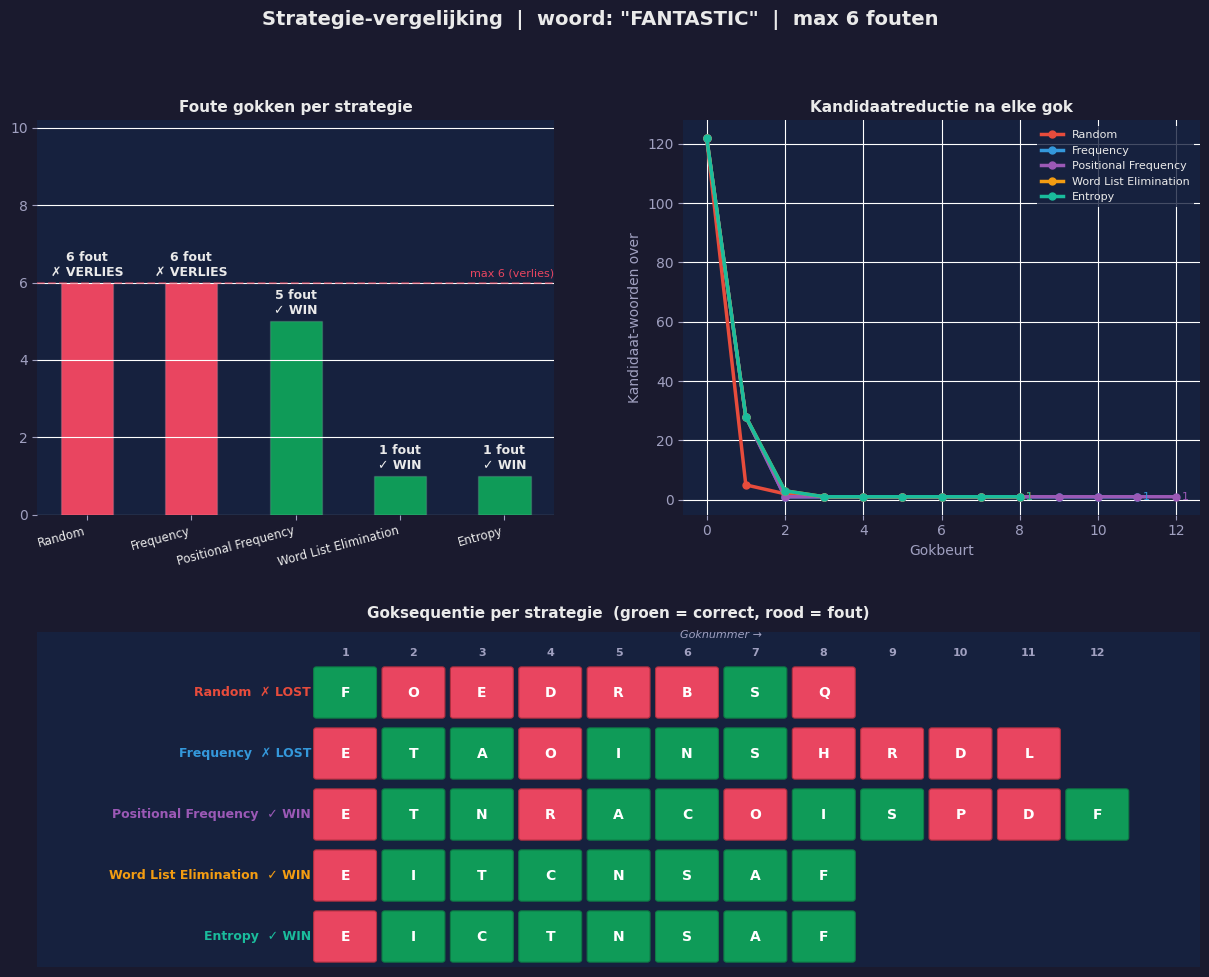

In [48]:
DEMO_WORD = "fantastic"
DEMO_MAX_WRONG = 6

# ─── Helper: filter candidates ────────────────────────────────────────────
def filter_candidates(word_list, state):
    """Return all words from word_list that are still consistent with the game state."""
    masked  = state["masked_word"]
    guessed = set(state["guessed_letters"])
    wlen    = state["word_length"]
    result  = []
    for word in word_list:
        if len(word) != wlen:
            continue
        ok = True
        for i, ch in enumerate(masked):
            if ch != "_":
                if word[i] != ch:
                    ok = False; break
            else:
                if word[i] in guessed:
                    ok = False; break
        if ok:
            result.append(word)
    return result

# ─── Run all agents on DEMO_WORD ─────────────────────────────────────────
agents_demo  = get_all_agents()
AGENT_COLORS = ['#E74C3C', '#3498DB', '#9B59B6', '#F39C12', '#1ABC9C']

demo_results = {}
for agent in agents_demo:
    env = HangmanEnvironment(word_list=FIXED_WORDS, max_wrong_guesses=DEMO_MAX_WRONG, seed=0)
    obs = env.reset(word=DEMO_WORD)
    candidate_trace = [len(filter_candidates(FIXED_WORDS, obs))]
    guess_log = []
    correct_log = []

    while not env.is_done:
        letter = agent.pick_letter(obs, FIXED_WORDS)
        result = env.step(letter)
        obs    = result.observation
        candidate_trace.append(len(filter_candidates(FIXED_WORDS, obs)))
        guess_log.append(letter)
        correct_log.append(result.info.get('correct', False))

    demo_results[agent.name] = {
        "won":        env.game.is_won,
        "wrong":      env.game.wrong_guesses,
        "guesses":    guess_log,
        "correct":    correct_log,
        "candidates": candidate_trace,
    }
    status = "✓ WIN" if env.game.is_won else f"✗ VERLIES (fout: {env.game.wrong_guesses})"
    print(f"{agent.name:<30}: {status}  | gokken: {guess_log}")

# ─── Plots ───────────────────────────────────────────────────────────────
names  = [a.name for a in agents_demo]
labels = [n.replace(' Agent', '') for n in names]
wrongs = [demo_results[n]["wrong"] for n in names]
won    = [demo_results[n]["won"]   for n in names]

fig = plt.figure(figsize=(15, 11), facecolor=PALETTE["bg"])
gs = fig.add_gridspec(2, 2, height_ratios=[1, 0.85], hspace=0.32, wspace=0.25)
fig.suptitle(
    f'Strategie-vergelijking  |  woord: "{DEMO_WORD.upper()}"  |  max {DEMO_MAX_WRONG} fouten',
    fontsize=14, fontweight='bold', color=PALETTE["text"], y=0.98
)

# ── Top-left: foute gokken per strategie ─────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(PALETTE["panel"])
ax1.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax1.tick_params(colors=PALETTE["subtext"])
ax1.grid(axis='y', color="#FFFFFF12", linewidth=0.8)

bar_cols = [PALETTE["correct"] if w else PALETTE["wrong"] for w in won]
bars = ax1.bar(labels, wrongs, color=bar_cols, edgecolor="#FFFFFF20", width=0.5)
for bar, val, w in zip(bars, wrongs, won):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{val} fout\n{'✓ WIN' if w else '✗ VERLIES'}",
        ha='center', va='bottom',
        fontsize=9, color=PALETTE["text"], fontweight='bold'
    )
ax1.set_ylim(0, max(wrongs + [1]) * 1.7)
ax1.set_title("Foute gokken per strategie", color=PALETTE["text"], fontsize=11, fontweight='bold')
ax1.set_xticklabels(labels, color=PALETTE["text"], fontsize=8.5, rotation=15, ha='right')
ax1.axhline(y=DEMO_MAX_WRONG, color=PALETTE["wrong"], linestyle='--', alpha=0.5, linewidth=1.5)
ax1.text(len(labels) - 0.52, DEMO_MAX_WRONG + 0.15,
         f"max {DEMO_MAX_WRONG} (verlies)", color=PALETTE["wrong"], fontsize=8, ha='right')

# ── Top-right: kandidaatreductie per gok ─────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(PALETTE["panel"])
ax2.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax2.tick_params(colors=PALETTE["subtext"])
ax2.grid(color="#FFFFFF12", linewidth=0.8)

for agent, color in zip(agents_demo, AGENT_COLORS):
    trace = demo_results[agent.name]["candidates"]
    lbl   = agent.name.replace(' Agent', '')
    ax2.plot(range(len(trace)), trace, marker='o', color=color, lw=2.5, markersize=5, label=lbl)
    ax2.text(len(trace) - 1 + 0.15, trace[-1], f"{trace[-1]}", color=color, va='center', fontsize=8)

ax2.set_xlabel("Gokbeurt", color=PALETTE["subtext"], fontsize=10)
ax2.set_ylabel("Kandidaat-woorden over", color=PALETTE["subtext"], fontsize=10)
ax2.set_title("Kandidaatreductie na elke gok", color=PALETTE["text"], fontsize=11, fontweight='bold')
ax2.legend(facecolor=PALETTE["panel"], labelcolor=PALETTE["text"], edgecolor="none", fontsize=8, loc='upper right')

# ── Bottom: goksequentie per strategie ───────────────────────────────────
ax3 = fig.add_subplot(gs[1, :])
ax3.set_facecolor(PALETTE["panel"])

max_guesses = max(len(demo_results[n]["guesses"]) for n in names)
n_rows = len(names)

ax3.set_xlim(-4.5, max_guesses + 0.5)
ax3.set_ylim(n_rows - 0.5, -1.0)
ax3.set_aspect('auto')
ax3.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax3.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax3.set_title("Goksequentie per strategie  (groen = correct, rood = fout)",
              color=PALETTE["text"], fontsize=11, fontweight='bold', pad=10)

# Column headers (guess number)
for col in range(max_guesses):
    ax3.text(col, -0.65, f"{col+1}", ha='center', va='center',
             fontsize=8, color=PALETTE["subtext"], fontweight='bold')
ax3.text(max_guesses / 2 - 0.5, -0.95, "Goknummer →",
         ha='center', va='center', fontsize=8, color=PALETTE["subtext"], style='italic')

for row, (agent_name, color) in enumerate(zip(names, AGENT_COLORS)):
    lbl = agent_name.replace(' Agent', '')
    result_str = "✓ WIN" if demo_results[agent_name]["won"] else "✗ LOST"
    ax3.text(-0.5, row, f"{lbl}  {result_str}",
             ha='right', va='center', fontsize=9, fontweight='bold', color=color)

    guesses = demo_results[agent_name]["guesses"]
    corrects = demo_results[agent_name]["correct"]

    for col, (letter, is_correct) in enumerate(zip(guesses, corrects)):
        bg = PALETTE["correct"] if is_correct else PALETTE["wrong"]
        edge = "#0D7A45" if is_correct else "#B03040"
        rect = mpatches.FancyBboxPatch(
            (col - 0.42, row - 0.38), 0.84, 0.76,
            boxstyle='round,pad=0.04',
            facecolor=bg, edgecolor=edge, lw=0.8
        )
        ax3.add_patch(rect)
        ax3.text(col, row, letter.upper(),
                 ha='center', va='center', fontsize=10,
                 fontweight='bold', color='white')

plt.tight_layout()
plt.show()


## 4. Stap-voor-stap Spelvisualisatie

Hieronder speelt de **Entropie-agent** één volledig spel op het woord `"evolution"` (9 letters), stap voor stap gevisualiseerd met **max 6 foute gokken**.  
Let op hoe de agent metodisch de kandidatenlijst reduceert — maar met meer woorden en strikte foutlimiet is het nu een echte uitdaging.

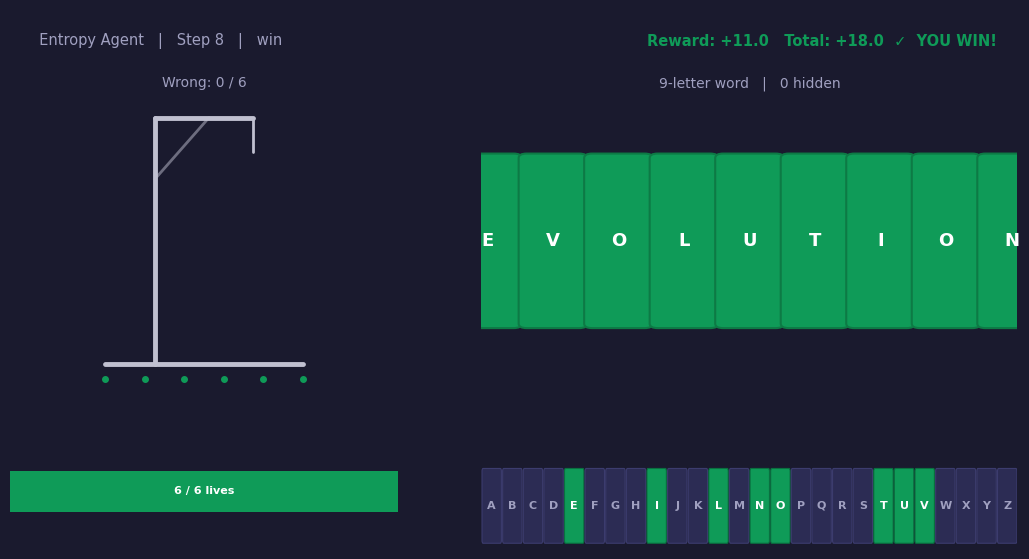


Spel afgerond in 8 gokken — GEWONNEN ✓
Foute gokken: 0 / 6


In [42]:
WATCH_WORD     = "evolution"
WATCH_MAX_WRONG = 6

env   = HangmanEnvironment(word_list=FIXED_WORDS, max_wrong_guesses=WATCH_MAX_WRONG, seed=1)
agent = EntropyAgent()
obs   = env.reset(word=WATCH_WORD)
step  = 0
total_reward = 0.0

while not env.is_done:
    letter = agent.pick_letter(obs, FIXED_WORDS)
    result = env.step(letter)
    step += 1
    total_reward += result.reward

    clear_output(wait=True)
    render_state(
        obs=result.observation,
        game=env.game,
        agent_name=agent.name,
        step=step,
        reward=result.reward,
        total_reward=total_reward,
        event=result.info['event'],
        delay=0.0,
    )
    obs = result.observation

print(f"\nSpel afgerond in {step} gokken — {'GEWONNEN ✓' if env.game.is_won else 'VERLOREN ✗'}")
print(f"Foute gokken: {env.game.wrong_guesses} / {env.game.max_wrong_guesses}")

## 5. Benchmark op de volledige woordenlijst

Alle vijf strategieën worden getest op **elk woord** uit de vaste woordenlijst, met **maximaal 6 foute gokken** per spel.

**Totaaloverzicht:**
- **Winpercentage** — hoe vaak wint de agent?
- **Gem. Foute Gokken** — minder fouten = efficiëntere strategie
- **Gem. beloning** — gebaseerd op het beloningsschema van de omgeving

**Uitsplitsing per woordlengte:**
- De **heatmap** en **gegroepeerde staafgrafiek** tonen het winpercentage van elke strategie per woordlengte (4 t/m 10 letters).
- Sommige strategieën presteren beter bij kortere woorden, andere bij langere — **er is niet altijd één beste strategie voor alle woordlengtes**.



Agent                             Win%   Gem.Fout   Gem.Beloning
────────────────────────────────────────────────────────────────
Random Agent                      0.5%       5.99        -14.39
Frequency Agent                   7.1%       5.86        -11.12
Positional Frequency Agent       20.9%       5.49         -7.48
Word List Elimination Agent      95.3%       2.04         12.35
Entropy Agent                    92.9%       2.17         11.62

Woordlengte            Random      FrequencyPositional FrequencyWord List Elimination        Entropy     Beste
───────────────────────────────────────────────────────────────────────────────────────────────────
   4 letters (272)           1.5%           5.9%          19.9%          79.4%          72.8%  ★ Word List Elimination
   5 letters (680)           0.6%           5.6%          14.3%          94.9%          91.3%  ★ Word List Elimination
   6 letters (376)           0.5%           6.4%          21.8%         100.0%          98.9%  ★ Wo

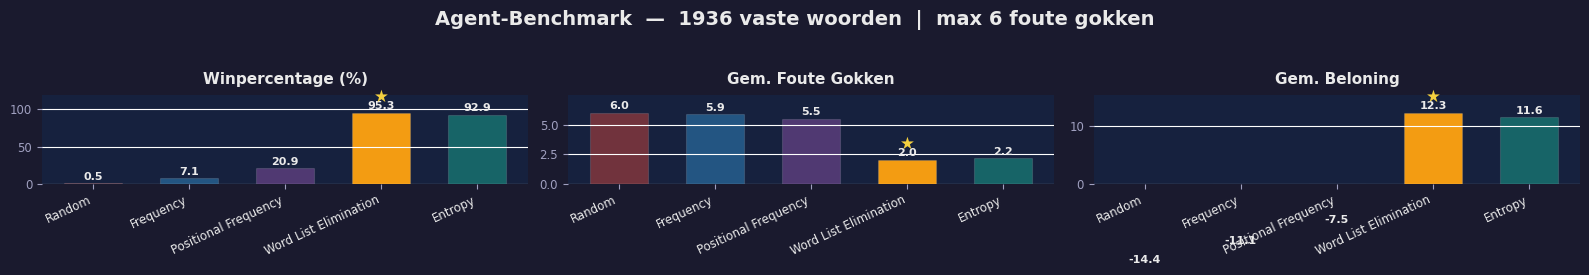

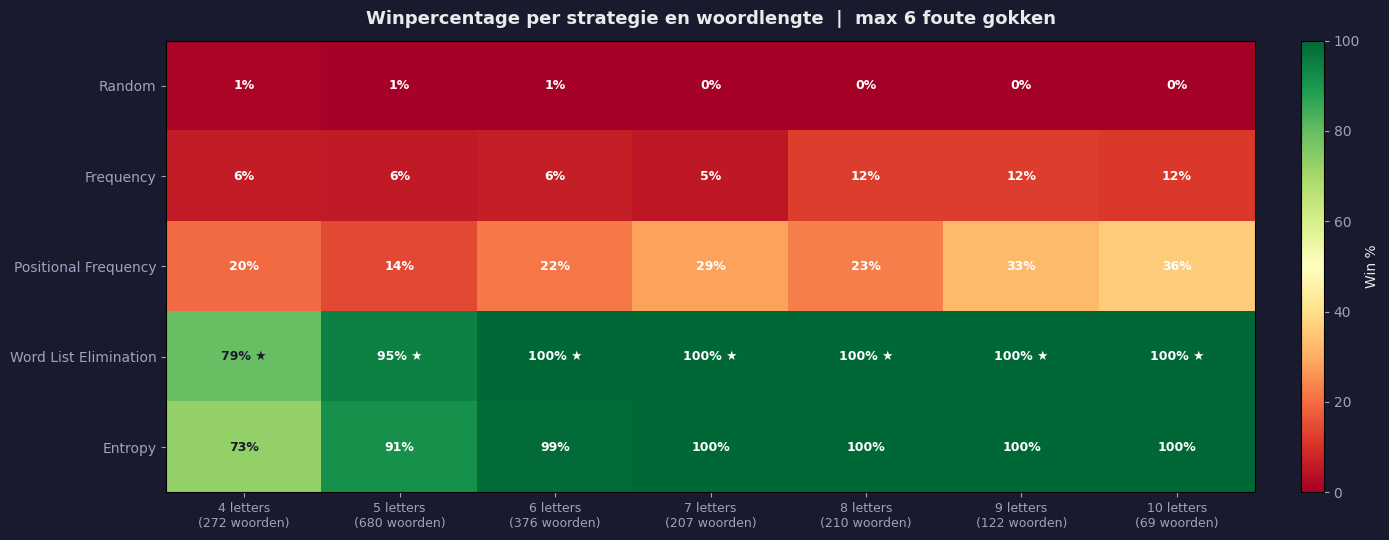

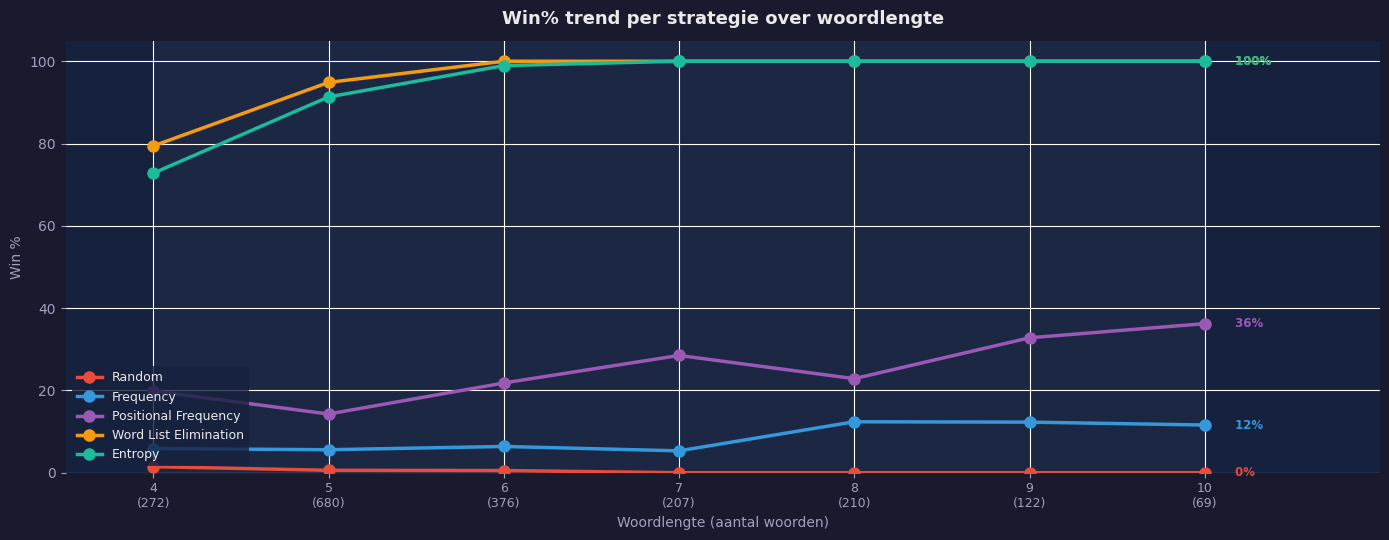

In [43]:
MAX_WRONG = 6   # standaard Hangman-regels
agents    = get_all_agents()

# ── Verzamel resultaten per woord ─────────────────────────────────────────
word_results = []  # list of dicts: agent, word, length, won, wrong, reward
for agent in agents:
    for word in FIXED_WORDS:
        env2 = HangmanEnvironment(word_list=FIXED_WORDS, max_wrong_guesses=MAX_WRONG)
        obs2 = env2.reset(word=word)
        ep_rew = 0.0
        while not env2.is_done:
            letter = agent.pick_letter(obs2, FIXED_WORDS)
            r      = env2.step(letter)
            ep_rew += r.reward
            obs2    = r.observation
        word_results.append({
            "agent":  agent.name,
            "word":   word,
            "length": len(word),
            "won":    env2.game.is_won,
            "wrong":  env2.game.wrong_guesses,
            "reward": ep_rew,
        })

# ── Totaal per agent ──────────────────────────────────────────────────────
bench_results = {}
for agent in agents:
    rows = [r for r in word_results if r["agent"] == agent.name]
    n = len(rows)
    bench_results[agent.name] = {
        "win_rate":   sum(r["won"] for r in rows) / n * 100,
        "avg_wrong":  sum(r["wrong"] for r in rows) / n,
        "avg_reward": sum(r["reward"] for r in rows) / n,
    }

print(f"\n{'Agent':<30} {'Win%':>7}  {'Gem.Fout':>9}  {'Gem.Beloning':>13}")
print("─" * 64)
for agent in agents:
    r = bench_results[agent.name]
    print(f"{agent.name:<30} {r['win_rate']:>6.1f}%  {r['avg_wrong']:>9.2f}  {r['avg_reward']:>12.2f}")

# ── Per woordlengte: win% per agent ───────────────────────────────────────
word_lengths = sorted(set(len(w) for w in FIXED_WORDS))
names  = [a.name for a in agents]
labels = [n.replace(' Agent', '') for n in names]
words_per_len = {wl: sum(1 for w in FIXED_WORDS if len(w) == wl) for wl in word_lengths}

length_win = {}  # {agent_name: {length: win%}}
for agent in agents:
    length_win[agent.name] = {}
    rows = [r for r in word_results if r["agent"] == agent.name]
    for wl in word_lengths:
        wl_rows = [r for r in rows if r["length"] == wl]
        if wl_rows:
            length_win[agent.name][wl] = sum(r["won"] for r in wl_rows) / len(wl_rows) * 100

# Print per-length tabel
print(f"\n{'Woordlengte':<14}", end="")
for lbl in labels:
    print(f"{lbl:>15}", end="")
print(f"{'  Beste':>10}")
print("─" * (14 + 15 * len(labels) + 10))
for wl in word_lengths:
    n_words = words_per_len[wl]
    print(f"  {wl:>2} letters ({n_words:>3})", end="")
    rates = []
    for agent in agents:
        wr = length_win[agent.name].get(wl, 0)
        rates.append(wr)
        print(f"{wr:>14.1f}%", end="")
    best_idx = rates.index(max(rates))
    print(f"  ★ {labels[best_idx]}")

# ── Grafiek 1: overall benchmark ─────────────────────────────────────────
metrics = [
    ('win_rate',   'Winpercentage (%)', True),
    ('avg_wrong',  'Gem. Foute Gokken', False),
    ('avg_reward', 'Gem. Beloning',     True),
]
BAR_COLORS = ['#E74C3C', '#3498DB', '#9B59B6', '#F39C12', '#1ABC9C']

fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor=PALETTE["bg"])
fig.suptitle(
    f'Agent-Benchmark  —  {len(FIXED_WORDS)} vaste woorden  |  max {MAX_WRONG} foute gokken',
    fontsize=14, fontweight='bold', color=PALETTE["text"], y=1.02,
)

for ax, (key, label, higher_better) in zip(axes, metrics):
    vals     = [bench_results[n][key] for n in names]
    best_idx = vals.index(max(vals)) if higher_better else vals.index(min(vals))
    bar_colors = []
    for idx in range(len(names)):
        c = BAR_COLORS[idx % len(BAR_COLORS)]
        bar_colors.append(c if idx == best_idx else c + "70")

    x    = np.arange(len(names))
    bars = ax.bar(x, vals, color=bar_colors, edgecolor="#FFFFFF20", width=0.6, linewidth=0.8)

    ax.set_facecolor(PALETTE["panel"])
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
    ax.tick_params(colors=PALETTE["subtext"], labelsize=8.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=8.5, color=PALETTE["text"])
    ax.grid(axis='y', color="#FFFFFF12", linewidth=0.8)

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(vals) * 0.02,
            f'{val:.1f}',
            ha='center', va='bottom',
            fontsize=8, color=PALETTE["text"], fontweight='bold'
        )
    best_bar = bars[best_idx]
    ax.text(
        best_bar.get_x() + best_bar.get_width() / 2,
        best_bar.get_height() + max(vals) * 0.10,
        "★", ha='center', va='bottom',
        fontsize=12, color=PALETTE["gold"]
    )
    ax.set_ylim(0, max(vals) * 1.25)
    ax.set_title(label, fontsize=11, color=PALETTE["text"], fontweight='bold', pad=8)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

# ── Grafiek 2: heatmap win% per agent × woordlengte ──────────────────────
data = np.array([[length_win[n].get(wl, 0) for wl in word_lengths] for n in names])

fig2, ax2 = plt.subplots(figsize=(14, 5.5), facecolor=PALETTE["bg"])
ax2.set_facecolor(PALETTE["panel"])

im = ax2.imshow(data, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
ax2.set_xticks(range(len(word_lengths)))
ax2.set_xticklabels(
    [f"{wl} letters\n({words_per_len[wl]} woorden)" for wl in word_lengths],
    fontsize=9, color=PALETTE["text"]
)
ax2.set_yticks(range(len(names)))
ax2.set_yticklabels(labels, fontsize=10, color=PALETTE["text"])
ax2.tick_params(colors=PALETTE["subtext"])

# Annotatie in elke cel + ster voor beste agent per lengte
for j, wl in enumerate(word_lengths):
    col_vals = [data[i, j] for i in range(len(names))]
    best_i = col_vals.index(max(col_vals))
    for i in range(len(names)):
        val = data[i, j]
        txt_color = "white" if val < 40 or val > 80 else "#1A1A2E"
        star = " ★" if i == best_i else ""
        ax2.text(j, i, f"{val:.0f}%{star}", ha='center', va='center',
                 fontsize=9, fontweight='bold', color=txt_color)

cbar = fig2.colorbar(im, ax=ax2, fraction=0.025, pad=0.04)
cbar.set_label('Win %', color=PALETTE["text"], fontsize=10)
cbar.ax.tick_params(colors=PALETTE["subtext"])

ax2.set_title(
    f'Winpercentage per strategie en woordlengte  |  max {MAX_WRONG} foute gokken',
    fontsize=13, fontweight='bold', color=PALETTE["text"], pad=12
)
fig2.tight_layout()
plt.show()

# ── Grafiek 3: lijndiagram win% trend per woordlengte ────────────────────
fig3, ax3 = plt.subplots(figsize=(14, 5.5), facecolor=PALETTE["bg"])
ax3.set_facecolor(PALETTE["panel"])
ax3.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax3.grid(color="#FFFFFF12", linewidth=0.8)

for agent_name, color in zip(names, BAR_COLORS):
    vals = [length_win[agent_name].get(wl, 0) for wl in word_lengths]
    lbl = agent_name.replace(' Agent', '')
    ax3.plot(word_lengths, vals, marker='o', color=color, lw=2.5, markersize=8,
             label=lbl, zorder=3)
    # Annotate endpoint
    ax3.text(word_lengths[-1] + 0.15, vals[-1], f" {vals[-1]:.0f}%",
             color=color, fontsize=8.5, va='center', fontweight='bold')

ax3.set_xticks(word_lengths)
ax3.set_xticklabels(
    [f"{wl}\n({words_per_len[wl]})" for wl in word_lengths],
    fontsize=9, color=PALETTE["text"]
)
ax3.set_xlabel("Woordlengte (aantal woorden)", fontsize=10, color=PALETTE["subtext"])
ax3.set_ylabel("Win %", fontsize=10, color=PALETTE["subtext"])
ax3.tick_params(colors=PALETTE["subtext"])
ax3.set_ylim(0, 105)
ax3.set_xlim(word_lengths[0] - 0.5, word_lengths[-1] + 1.0)
ax3.legend(facecolor=PALETTE["panel"], labelcolor=PALETTE["text"],
           edgecolor="none", fontsize=9, loc='lower left')
ax3.set_title(
    f'Win% trend per strategie over woordlengte',
    fontsize=13, fontweight='bold', color=PALETTE["text"], pad=12
)

# Highlight areas where different agents excel
ax3.fill_between(word_lengths, 0, 105, alpha=0.03, color=PALETTE["text"])

fig3.tight_layout()
plt.show()


## 6. Conclusie

De benchmark bevestigt de strategie-hiërarchie — elke stap voegt meetbare waarde toe:

- **Random** wint zelden — volledig afhankelijk van geluk.
- **Frequentie** scoort iets beter door veelvoorkomende letters eerst te proberen, maar negeert de woordenlijst.
- **Positionele Frequentie** benut de woordlijststatistieken per positie en scoort merkbaar beter, maar filtert niet actief op het spelverloop.
- **Woordeliminatie** maakt een grote sprong: actief filteren en kiezen van de meest-voorkomende letter in de kandidatenlijst is zeer effectief.
- **Entropie** is de sterkste strategie. Door de letter te kiezen die de kandidatenlijst het meest *gelijkmatig opsplitst*, haalt de agent maximale informatie uit elke gok — zowel correcte als foute. Op het allerlaatste leven schakelt de agent over naar een overlevingsmodus die riskante gokken vermijdt.

### Waarom wint Entropie van Woordeliminatie?

Woordeliminatie kiest de letter die in de *meeste* kandidaten voorkomt — dit maximaliseert de kans op een hit. Maar twee letters met dezelfde hit-kans kunnen de kandidatenlijst heel anders opsplitsen. De entropie-agent kiest altijd de letter die de meeste **informatiewinst** oplevert, ongeacht of het een hit of een miss wordt.

### Kernles

> **Een vaste woordenlijst is niet alleen de speelruimte — het is de kennisbasis.**
> De entropie-agent wint door elke gok te behandelen als een **informatietheorie-vraag**: welke letter levert het meeste bits op?